# ALML CA1
## Part B: Housing Price Regression Analysis
### Risalat Masrafi
### P2508290


# Introduction
This notebook predicts housing prices using features such as city, house area, number of bedrooms, toilets, stories, and renovation status.  

The workflow includes:

- Loading libraries and dataset  
- Exploratory Data Analysis (EDA)  
- Data Processing  
- Model comparison  
- Baseline model evaluation  
- Hyperparameter tuning  
- Final model evaluation


# 1. Loading Libraries and Dataset
We start by importing necessary libraries for data manipulation, visualization, preprocessing, modeling, and evaluation.



In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, KFold, train_test_split, StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np


In [2]:
# Load dataset
hs_df = pd.read_csv("housing_price_data.csv")
hs_df.head()

,House ID,City,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,Price ($)
0,0,Chicago,742.0,4,2,3,furnished,1330000
1,1,Denver,896.0,4,4,4,furnished,1225000
2,2,Chicago,996.0,3,2,2,semi-furnished,1225000
3,3,Seattle,750.0,4,2,2,furnished,1221500
4,4,New York,742.0,4,1,2,furnished,1141000


In [3]:
print(hs_df.isna().sum(),
      hs_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   House ID           545 non-null    int64  
 1   City               545 non-null    object 
 2   House Area (sqm)   545 non-null    float64
 3   No. of Bedrooms    545 non-null    int64  
 4   No. of Toilets     545 non-null    int64  
 5   Stories            545 non-null    int64  
 6   Renovation Status  545 non-null    object 
 7   Price ($)          545 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 34.2+ KB
House ID             0
City                 0
House Area (sqm)     0
No. of Bedrooms      0
No. of Toilets       0
Stories              0
Renovation Status    0
Price ($)            0
dtype: int64 None


# 3. Exploratory Data Analysis (EDA)
- Understand the distribution of housing prices
- Examine price differences by city and renovation status
- Explore relationships between numerical features and price using scatter plots and correlations


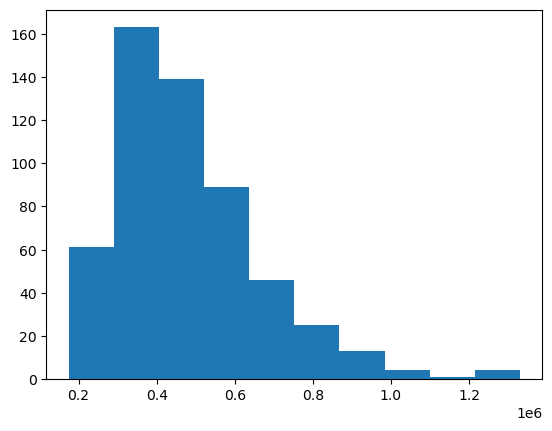

In [4]:
plt.hist(hs_df["Price ($)"])
plt.show()

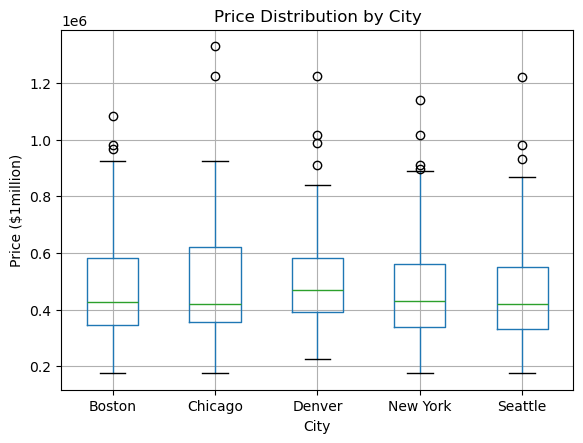

In [5]:
hs_df.boxplot(column="Price ($)", by="City")
plt.title("Price Distribution by City")
plt.suptitle("")
plt.ylabel("Price ($1million)")
plt.show()

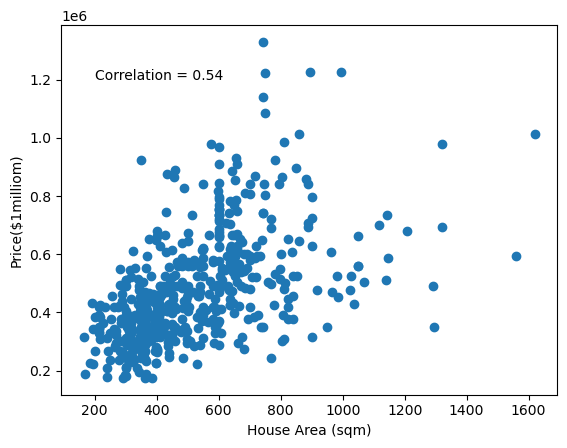

In [6]:
plt.scatter(hs_df["House Area (sqm)"],hs_df["Price ($)"])
plt.xlabel("House Area (sqm)")
plt.ylabel("Price($1milliom)")

corr = np.corrcoef(hs_df["House Area (sqm)"], hs_df["Price ($)"])[0, 1]
plt.text(
    x=200, y=1200000,  # adjust position as needed
    s=f"Correlation = {corr:.2f}",
    fontsize=10
)



plt.show()

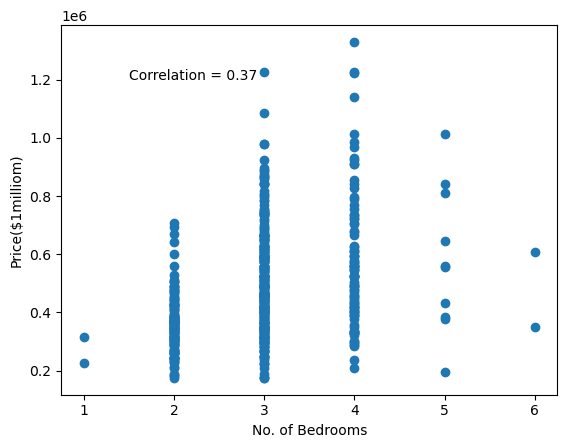

In [7]:
plt.scatter(hs_df["No. of Bedrooms"],hs_df["Price ($)"])
plt.xlabel("No. of Bedrooms")
plt.ylabel("Price($1milliom)")

corr = np.corrcoef(hs_df["No. of Bedrooms"], hs_df["Price ($)"])[0, 1]
plt.text(
    x=1.5, y=1200000,  # adjust position as needed
    s=f"Correlation = {corr:.2f}",
    fontsize=10
)



plt.show()

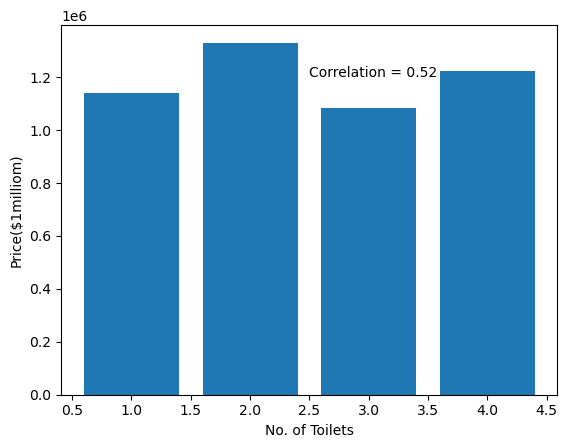

In [8]:
plt.bar(hs_df["No. of Toilets"],hs_df["Price ($)"])
plt.xlabel("No. of Toilets")
plt.ylabel("Price($1milliom)")

corr = np.corrcoef(hs_df["No. of Toilets"], hs_df["Price ($)"])[0, 1]
plt.text(
    x=2.5, y=1200000,  # adjust position as needed
    s=f"Correlation = {corr:.2f}",
    fontsize=10
)



plt.show()

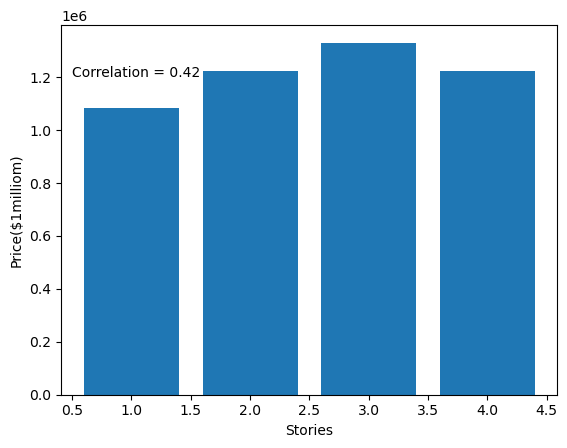

In [9]:
plt.bar(hs_df["Stories"],hs_df["Price ($)"])
plt.xlabel("Stories")
plt.ylabel("Price($1milliom)")

corr = np.corrcoef(hs_df["Stories"], hs_df["Price ($)"])[0, 1]
plt.text(
    x=0.5, y=1200000,  # adjust position as needed
    s=f"Correlation = {corr:.2f}",
    fontsize=10
)



plt.show()

# 4. Data Processing
- Drop Unnecessary columns like *House ID*
- Split dataset into features(X) and Target(y)
- Split the dataset into training and test sets
- Encode categorical features:
  - Renovation Status → ordinal encoding
  - City → one-hot encoding
- Scale numerical features using StandardScaler for model training


In [10]:
hs_df.drop("House ID", axis=1, inplace=True)
hs_df

,City,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,Price ($)
0,Chicago,742.0,4,2,3,furnished,1330000
1,Denver,896.0,4,4,4,furnished,1225000
2,Chicago,996.0,3,2,2,semi-furnished,1225000
3,Seattle,750.0,4,2,2,furnished,1221500
4,New York,742.0,4,1,2,furnished,1141000
...,...,...,...,...,...,...,...
540,Seattle,300.0,2,1,1,unfurnished,182000
541,New York,240.0,3,1,1,semi-furnished,176715
542,Boston,362.0,2,1,1,unfurnished,175000
543,Seattle,291.0,3,1,1,furnished,175000


In [11]:
X = hs_df.drop("Price ($)", axis=1)
y = hs_df["Price ($)"].values

print(X.shape)
print(y.shape)


(545, 6)
(545,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

In [13]:
# Example: Renovation Status ordinal
furnish_order = {"unfurnished": 0, "semi-furnished": 1, "furnished": 2}
X_train["Renovation Status"] = X_train["Renovation Status"].map(furnish_order)
X_test["Renovation Status"] = X_test["Renovation Status"].map(furnish_order)


X_train = pd.get_dummies(X_train, columns=["City"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["City"], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Model Selection and Evaluation
- Compare multiple regression models using 5-fold cross-validation
- Models included:
  - Linear Regression (LinReg)
  - Ridge Regression
  - Lasso Regression
  - Support Vector Regressor (SVR)
- Evaluate performance using Mean Absolute Error (MAE)


LinReg: Mean MAE = 94453.79 | Std = 3223.41
Ridge: Mean MAE = 94442.47 | Std = 3227.21
Lasso: Mean MAE = 94453.79 | Std = 3223.41
SVR: Mean MAE = 143961.00 | Std = 10293.25


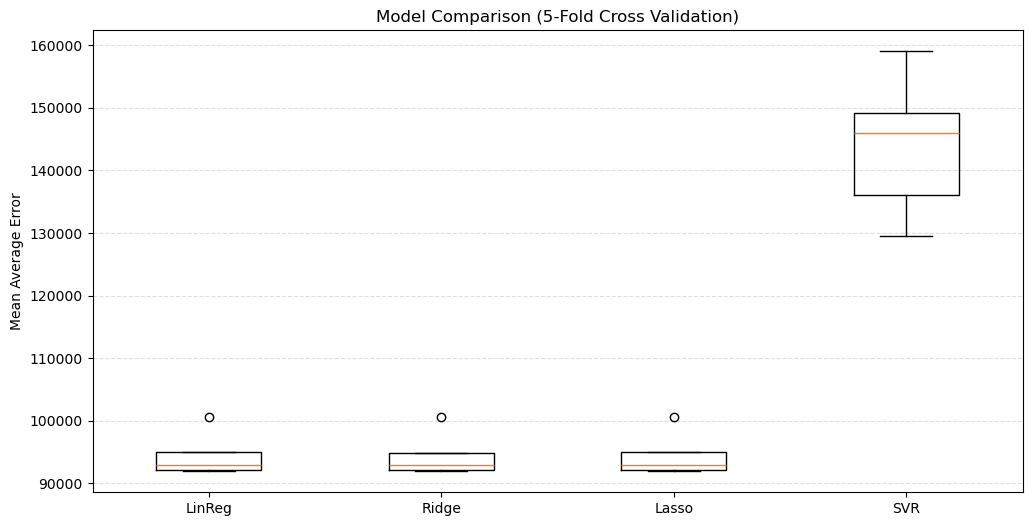

In [15]:
models = {
    "LinReg": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "SVR": SVR(kernel='rbf')
}

kf = KFold(n_splits=5, shuffle=True, random_state=67)
results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_scaled, y_train,
        scoring='neg_mean_absolute_error',
        cv=kf,
        n_jobs=-1
    )
    
    mae_scores = -scores   # convert neg MAE → positive MAE
    
    results.append(mae_scores)
    print(f"{name}: Mean MAE = {mae_scores.mean():.2f} | Std = {mae_scores.std():.2f}")

# Boxplot of results
plt.figure(figsize=(12,6))
plt.boxplot(results, tick_labels=list(models.keys()))
plt.ylabel("Mean Average Error")
plt.title("Model Comparison (5-Fold Cross Validation)")
plt.grid(axis="y", linestyle="--", alpha=0.4)


# 6. Baseline Model
- Establish a baseline using Dummy Regressor (predicting the mean)
- Compare MAE to see improvement from actual models


In [16]:


dummy = DummyRegressor(strategy="mean")

dummy_scores = cross_val_score(
    dummy,
    X_train_scaled,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=5
)

dummy_mae = -dummy_scores.mean()
print("Dummy MAE:", dummy_mae)


Dummy MAE: 148306.11406612565


# 7. Hyperparameter Tuning (Ridge)
- Tune `alpha` for Ridge regression using GridSearchCV
- Goal: minimize Mean Absolute Error
- Use 5-fold cross-validation


In [17]:
# Alpha range
alphas = np.linspace(1, 100, 500)

ridge = Ridge()

param_grid = {"alpha": alphas}

search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error', 
    cv=kf,
    n_jobs=-1,
    verbose=2,
    refit=True
)

# Fit using scaled X
search.fit(X_train_scaled, y_train)

# Best alpha and MAE
best_alpha = search.best_params_["alpha"]
best_mae = -search.best_score_

print("Best alpha:", best_alpha)
print("Best MAE:", best_mae)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Best alpha: 24.014028056112224
Best MAE: 94382.58195313593


# 8. Final Ridge Model Evaluation
- Train Ridge with best alpha on the training set
- Evaluate on test set using MAE


In [18]:
# Train Ridge on scaled training data
rid = Ridge(alpha= 24.014028056112224)
rid.fit(X_train_scaled, y_train)

# Predict on scaled test set
y_pred = rid.predict(X_test_scaled)

# Compute MAE
mae = mean_absolute_error(y_test, y_pred)
print("Test MAE:", mae)

Test MAE: 83805.13515368594


# Summary and Conclusion

- This project predicted **housing prices** using features like city, house area, number of bedrooms, toilets, stories, and renovation status.
- **Exploratory Data Analysis (EDA)** revealed:
  - Prices vary by city and renovation status
  - Moderate correlation between house area and price
  - Weak correlation between number of bedrooms, toilets, stories, and price
- **Model Comparison**:
  - Ridge regression performed slightly better than Linear and Lasso regression
  - SVR had the highest MAE, likely due to scaling and small dataset size
  - Baseline Dummy Regressor MAE was 148306.11
- **Hyperparameter Tuning**:
  - Ridge alpha optimized to **24.01** using GridSearchCV
  - Cross-validated MAE improved to **94382.58**
- **Final Evaluation**:
  - Test set MAE using tuned Ridge: **83805.14**
  - Demonstrates clear improvement over baseline and untuned models
- **Key Insights**:
  - Feature scaling and encoding are crucial for performance
  - Ridge regression with proper alpha tuning is effective for this housing price dataset
  - EDA is useful to identify strong predictors and potential preprocessing steps
